# Timepill 0422 Prototype Detector

## 업로드 방법
1. `0422/` 폴더 전체를 Google Drive 루트에 업로드 (`MyDrive/0422/`)
2. Drive 루트에 아래 폴더들이 있어야 함:
   - `pill.yolov8/` — 실제 알약 labeled 이미지
   - `sample_img/` — 합성용 알약 컷아웃
   - `backgrounds/` — 합성용 배경 이미지
   - `hard_negatives/` — 혼동하기 쉬운 비알약 이미지
   - `aihub이미지데이터/` — AIHub zip 데이터 (Step 3b)

## 실행 순서
Step 1 → Step 2 → Step 3a → Step 3b (AIHub 있을 때) → Step 4 → ...


## !! 최초 실행 전 확인
- synthetic 생성 코드가 업데이트됨 (shadow, alpha, occluder 수정)
- build 셀의  주석을 **한 번만** 해제하고 실행할 것
- 실행 완료 후 다시 주석 처리할 것 (그대로 두면 매번 캐시 전체 재생성됨)

In [1]:
import subprocess
import torch

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('cuda device count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('gpu name:', torch.cuda.get_device_name(0))
else:
    print('GPU not available. In Colab, switch to Runtime > Change runtime type > GPU.')

try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout if result.stdout else result.stderr)
except FileNotFoundError:
    print('nvidia-smi not found in this runtime.')

torch version: 2.10.0+cu128
cuda available: True
cuda device count: 1
gpu name: Tesla T4
Mon Apr 27 01:34:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |        

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/0422
!pip install -q ultralytics pillow

/content/drive/MyDrive/0422


In [ ]:
# Step 3a: pill.yolov8 압축 해제 (.7z 및 .zip 모두 지원)
# Drive에 저장된 pill.yolov8.7z (또는 pill.yolov8.zip)을 /content/pill.yolov8/에 풀어서 빠른 로컬 접근 사용

import shutil, zipfile, subprocess
from pathlib import Path

DRIVE    = Path('/content/drive/MyDrive')
PILL_7Z  = DRIVE / 'pill.yolov8.7z'   # 7-Zip으로 생성한 경우
PILL_ZIP = DRIVE / 'pill.yolov8.zip'  # 기존 zip 경로 (fallback)
PILL_OUT = Path('/content/pill.yolov8')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

def count_images(root: Path) -> int:
    return sum(1 for p in root.rglob('*') if p.suffix.lower() in IMG_EXTS)

def normalize_extracted(tmp: Path, dest: Path):
    """압축 해제 후 폴더 구조 정규화: train/ 폴더가 바로 있으면 그대로, 한 단계 더 있으면 올려줌."""
    if (tmp / 'train').exists():
        if dest.exists(): shutil.rmtree(str(dest))
        shutil.move(str(tmp), str(dest))
    else:
        subdirs = [d for d in tmp.iterdir() if d.is_dir()]
        if len(subdirs) == 1 and (subdirs[0] / 'train').exists():
            if dest.exists(): shutil.rmtree(str(dest))
            shutil.move(str(subdirs[0]), str(dest))
            shutil.rmtree(str(tmp), ignore_errors=True)
        else:
            raise RuntimeError(
                f'7z/zip 내부 구조 인식 실패. 확인 필요: {[d.name for d in tmp.iterdir()]}'
            )

existing = count_images(PILL_OUT) if PILL_OUT.exists() else 0
if existing > 0:
    print(f'/content/pill.yolov8 이미 존재 ({existing}장) — 스킵')
elif PILL_7Z.exists():
    print(f'7z 압축 해제 중: {PILL_7Z}')
    subprocess.run(['apt-get', 'install', '-y', 'p7zip-full'],
                   check=True, capture_output=True)
    TMP = Path('/content/_pill_7z_tmp')
    if TMP.exists(): shutil.rmtree(str(TMP))
    TMP.mkdir(parents=True)
    subprocess.run(['7z', 'x', str(PILL_7Z), f'-o{TMP}', '-y'], check=True)
    normalize_extracted(TMP, PILL_OUT)
    total = count_images(PILL_OUT)
    print(f'완료: {total}장 → {PILL_OUT}')
elif PILL_ZIP.exists():
    print(f'압축 해제 중: {PILL_ZIP}')
    TMP = Path('/content/_pill_zip_tmp')
    if TMP.exists(): shutil.rmtree(str(TMP))
    TMP.mkdir(parents=True)
    with zipfile.ZipFile(str(PILL_ZIP), 'r') as z:
        z.extractall(str(TMP))
    normalize_extracted(TMP, PILL_OUT)
    total = count_images(PILL_OUT)
    print(f'완료: {total}장 → {PILL_OUT}')
else:
    raise FileNotFoundError(
        f'Drive에 pill.yolov8.7z 또는 pill.yolov8.zip 없음. '
        'pill.yolov8 폴더를 압축해 Drive 루트에 업로드하세요.'
    )

In [ ]:
# Step 3b: AIHub 데이터 준비
# 우선순위: 1) /content/aihub_600 이미 있음 → 스킵
#           2) Drive/aihub_600.zip 있음 → 압축해제만 (빠름)
#           3) 둘 다 없음 → raw 추출 + 전처리 → Drive에 zip 저장 (최초 1회)

import shutil, zipfile
from pathlib import Path

DRIVE    = Path('/content/drive/MyDrive')
AIHUB_OUT  = Path('/content/aihub_600')
AIHUB_ZIP  = DRIVE / 'aihub_600.zip'
IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.webp'}

def count_images(root: Path) -> int:
    return sum(1 for p in root.rglob('*') if p.suffix.lower() in IMG_EXTS)

# ── 1단계: 이미 로컬에 있으면 스킵 ──
if AIHUB_OUT.exists() and count_images(AIHUB_OUT) > 0:
    print(f'[스킵] /content/aihub_600 이미 존재 ({count_images(AIHUB_OUT)}장)')

# ── 2단계: Drive에 zip 있으면 압축해제 ──
elif AIHUB_ZIP.exists():
    print(f'[캐시] {AIHUB_ZIP} 압축 해제 중...')
    if AIHUB_OUT.exists():
        shutil.rmtree(str(AIHUB_OUT))
    AIHUB_OUT.mkdir(parents=True)
    with zipfile.ZipFile(str(AIHUB_ZIP), 'r') as z:
        z.extractall(str(AIHUB_OUT))
    print(f'[캐시] 완료: {count_images(AIHUB_OUT)}장')

# ── 3단계: 최초 실행 — raw 추출 + 전처리 + Drive에 zip 저장 ──
else:
    import random, math
    from PIL import Image, ImageDraw
    import matplotlib.pyplot as plt

    BASE             = DRIVE / 'aihub이미지데이터/01.데이터/1.Training'
    IMAGES_OUT_DRIVE = DRIVE / 'aihub_extracted/images'
    LABELS_OUT_DRIVE = DRIVE / 'aihub_extracted/labels'
    IMAGES_OUT       = Path('/content/aihub_images')
    LABELS_OUT       = Path('/content/aihub_labels')
    IMG_FOLDERS      = ['단일경구약제 5000종']

    def extract_zips(base, subfolder, out_dir, prefix):
        src_dir = base / prefix / subfolder
        if not src_dir.exists():
            print(f'  폴더 없음: {src_dir}'); return
        for z_path in sorted(src_dir.glob('*.zip')):
            marker = out_dir / f'.extracted_{z_path.stem}'
            if marker.exists():
                print(f'  이미 추출됨: {z_path.name}'); continue
            print(f'  추출 중: {z_path.name}')
            with zipfile.ZipFile(str(z_path), 'r') as z:
                z.extractall(str(out_dir))
            marker.touch()

    # Drive 캐시 확인
    images_in_drive = IMAGES_OUT_DRIVE.exists() and any(IMAGES_OUT_DRIVE.rglob('*'))
    labels_in_drive = LABELS_OUT_DRIVE.exists() and any(
        f for f in LABELS_OUT_DRIVE.rglob('*') if f.suffix.lower() == '.json')
    if not images_in_drive or not labels_in_drive:
        IMAGES_OUT_DRIVE.mkdir(parents=True, exist_ok=True)
        LABELS_OUT_DRIVE.mkdir(parents=True, exist_ok=True)
        for folder in IMG_FOLDERS:
            if not images_in_drive: extract_zips(BASE, folder, IMAGES_OUT_DRIVE, '원천데이터')
            if not labels_in_drive: extract_zips(BASE, folder, LABELS_OUT_DRIVE, '라벨링데이터')
    else:
        print('[Drive 캐시 확인됨] 이미지/라벨 모두 존재')

    # Drive → /content/ 복사
    need_imgs = not IMAGES_OUT.exists() or not any(IMAGES_OUT.rglob('*'))
    need_lbls = not LABELS_OUT.exists() or not any(
        f for f in LABELS_OUT.rglob('*') if f.suffix.lower() == '.json')
    if need_imgs or need_lbls:
        print('Drive → /content/ 복사 중...')
        if need_imgs:
            if IMAGES_OUT.exists(): shutil.rmtree(str(IMAGES_OUT))
            shutil.copytree(str(IMAGES_OUT_DRIVE), str(IMAGES_OUT))
        if need_lbls:
            if LABELS_OUT.exists(): shutil.rmtree(str(LABELS_OUT))
            shutil.copytree(str(LABELS_OUT_DRIVE), str(LABELS_OUT))
    else:
        print('/content/ 데이터 이미 있음, 복사 스킵')

    # 전처리
    print('[전처리] preprocess_aihub.py 실행 중...')
    import subprocess
    result = subprocess.run([
        'python', 'preprocess_aihub.py',
        '--images-dir', str(IMAGES_OUT),
        '--labels-dir', str(LABELS_OUT),
        '--output-dir', str(AIHUB_OUT),
        '--total-cap', '600',
        '--per-drug-cap', '0',
        '--max-bboxes-per-image', '0',
        '--angle-90-ratio', '0.20',
        '--val-ratio', '0',
    ], capture_output=False)

    # Drive에 zip으로 저장 (다음 세션에서 2단계로 빠르게 로드)
    print(f'[저장] {AIHUB_ZIP} 압축 중...')
    with zipfile.ZipFile(str(AIHUB_ZIP), 'w', zipfile.ZIP_DEFLATED) as zf:
        for p in AIHUB_OUT.rglob('*'):
            if p.is_file():
                zf.write(p, p.relative_to(AIHUB_OUT))
    print(f'[저장] 완료 → {AIHUB_ZIP} ({AIHUB_ZIP.stat().st_size / 1e6:.1f} MB)')

# ── 결과 카운트 ──
counts = {}
for split in ('train', 'val'):
    imgs = list((AIHUB_OUT / 'images' / split).glob('*'))
    counts[split] = len(imgs)
    print(f'  AIHub {split}: {len(imgs)}장')
print(f'  AIHub 합계: {sum(counts.values())}장')


In [ ]:
# Hard Negative augmentation cache (incremental: 새 이미지만 처리, 삭제/교체 자동 감지)

!python augment_hard_negatives_cache.py --hard-negatives-dir /content/drive/MyDrive/hard_negatives --cache-dir /content/drive/MyDrive/hard_negative_cache_aug --crops-per-image 1


In [ ]:
# Step 4a: Synthetic cache 준비
# USE_SYNTHETIC = False 이면 이 셀 전체를 건너뜀

USE_SYNTHETIC = False  # synthetic 쓸 때만 True로 변경

if not USE_SYNTHETIC:
    print('[건너뜀] USE_SYNTHETIC=False — synthetic 캐시 준비 생략')
else:
    # 우선순위: 1) /content/synthetic_cache_bgaug 이미 있음 → 건너뜀
    #           2) Drive/synthetic_cache_bgaug.zip 있음 → 압축해제 (빠름)
    #           3) 둘 다 없음 → 새로 생성 후 Drive에 zip 저장 (최초 1회)

    import shutil, zipfile, subprocess
    from pathlib import Path

    DRIVE     = Path('/content/drive/MyDrive')
    SYN_OUT   = Path('/content/synthetic_cache_bgaug')
    SYN_ZIP   = DRIVE / 'synthetic_cache_bgaug.zip'
    SYN_SIZE  = 1000  # synthetic_cache_size와 맞춰두기
    IMG_EXTS_SYN = {'.jpg', '.jpeg', '.png', '.webp'}

    def count_syn(root: Path) -> int:
        return sum(1 for p in root.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTS_SYN)

    existing = count_syn(SYN_OUT) if SYN_OUT.exists() else 0

    if existing >= SYN_SIZE:
        print(f'[건너뜀] /content/synthetic_cache_bgaug 이미 준비 ({existing}장)')

    elif SYN_ZIP.exists():
        print(f'[캐시] {SYN_ZIP} 압축 해제 중...')
        if SYN_OUT.exists():
            shutil.rmtree(str(SYN_OUT))
        SYN_OUT.mkdir(parents=True)
        with zipfile.ZipFile(str(SYN_ZIP), 'r') as z:
            z.extractall(str(SYN_OUT))
        print(f'[캐시] 완료: {count_syn(SYN_OUT)}장')

    else:
        print('[최초 생성] synthetic cache 생성 중 (시간 소요)...')
        subprocess.run([
            'python', 'build_real_prototype_dataset.py',
            '--real-root', str(DRIVE),
            '--output-root', '/content/datasets/_tmp_cache_only',
            '--synthetic-cache-dir', str(SYN_OUT),
            '--synthetic-cache-size', str(SYN_SIZE),
            '--background-augment-copies', '3',
            '--seed', '123',
            '--cache-only',
        ], check=True)
        print(f'[저장] {SYN_ZIP} 압축 중...')
        with zipfile.ZipFile(str(SYN_ZIP), 'w', zipfile.ZIP_DEFLATED) as zf:
            for p in SYN_OUT.rglob('*'):
                if p.is_file():
                    zf.write(p, p.relative_to(SYN_OUT))
        print(f'[저장] 완료 → {SYN_ZIP} ({SYN_ZIP.stat().st_size / 1e6:.1f} MB)')

In [ ]:
import subprocess
from pathlib import Path

DRIVE = Path('/content/drive/MyDrive')

cmd = [
    'python', 'build_real_prototype_dataset.py',
    '--real-root', str(DRIVE),
    '--output-root', '/content/datasets/pill_prototype_0422',
    '--copy-hard-negatives', '--hard-negative-cache-dir', str(DRIVE / 'hard_negative_cache_aug'),
    '--skip-synthetic',
    '--val-ratio', '0.25',
    '--test-ratio', '0',
    '--seed', '123',
    '--aihub-root', '/content/aihub_600',
    '--pill-yolov8-dir', '/content/pill.yolov8',
]

subprocess.run(cmd, check=True)


카테고리                    Train    Val   Test     합계
────────────────────────────────────────────────
Real Positive             283    106      0    389
AIHub Positive            222      0      0    222
Hard Negative             193     45      0    238
Synthetic Positive        150      0      0    150
────────────────────────────────────────────────
TOTAL                     848    151      0    999


/tmp/ipykernel_49729/2594215082.py:62: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49729/2594215082.py:62: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49729/2594215082.py:62: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49729/2594215082.py:62: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49729/2594215082.py:62: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49729/2594215082.py:62: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49729/2594215082.py:62: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) DejaVu Sans.
  plt.tight_

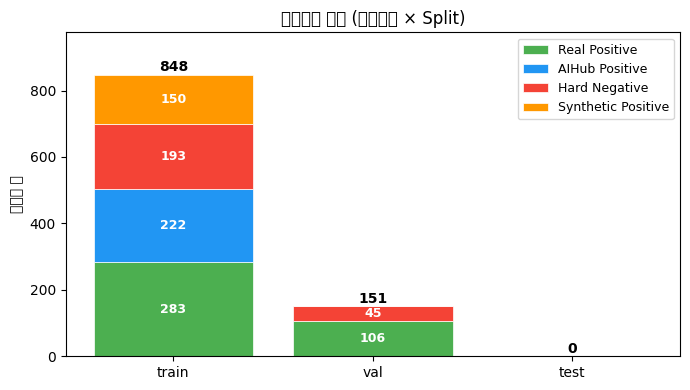

In [6]:
import math, random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('/content/datasets/pill_prototype_0422')
SUFFIXES = {'.jpg', '.jpeg', '.png', '.webp'}

CATEGORIES = [
    ('real_positive',      'Real Positive',      '#4CAF50'),
    ('aihub_positive',     'AIHub Positive',     '#2196F3'),
    ('hard_negative',      'Hard Negative',      '#F44336'),
    ('synthetic_positive', 'Synthetic Positive', '#FF9800'),
]

def classify(name):
    if name.startswith('syn_'):   return 'synthetic_positive'
    if name.startswith('neg_'):   return 'hard_negative'
    if name.startswith('aihub_'): return 'aihub_positive'
    return 'real_positive'

data = {cat: {s: 0 for s in ('train', 'val', 'test')} for cat, *_ in CATEGORIES}
for split in ('train', 'val', 'test'):
    img_dir = ROOT / 'images' / split
    if not img_dir.exists(): continue
    for p in img_dir.iterdir():
        if p.is_file() and p.suffix.lower() in SUFFIXES:
            data[classify(p.name)][split] += 1

# ── 표 출력 ──
print(f'\n{"카테고리":<22} {"Train":>6} {"Val":>6} {"Test":>6} {"합계":>6}')
print('─' * 48)
for cat, label, _ in CATEGORIES:
    t, v, te = data[cat]['train'], data[cat]['val'], data[cat]['test']
    print(f'{label:<22} {t:>6} {v:>6} {te:>6} {t+v+te:>6}')
print('─' * 48)
tr = sum(data[c]['train'] for c, *_ in CATEGORIES)
va = sum(data[c]['val']   for c, *_ in CATEGORIES)
te = sum(data[c]['test']  for c, *_ in CATEGORIES)
print(f'{"TOTAL":<22} {tr:>6} {va:>6} {te:>6} {tr+va+te:>6}')

# ── 누적 막대 차트 ──
splits = ['train', 'val', 'test']
fig, ax = plt.subplots(figsize=(7, 4))
bottoms = np.zeros(3)
for cat, label, color in CATEGORIES:
    vals = np.array([data[cat][s] for s in splits])
    bars = ax.bar(splits, vals, bottom=bottoms, color=color, label=label, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(val), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += vals
for i, total in enumerate(bottoms):
    ax.text(i, total + 1, str(int(total)), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('이미지 수')
ax.set_title('데이터셋 구성 (카테고리 × Split)')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, max(bottoms) * 1.15)
plt.tight_layout()
plt.show()


In [7]:
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

DATASET_ROOT = Path('/content/datasets/pill_prototype_0422')
PREVIEW_SEED = 42
SAMPLES_PER_GROUP = 6
IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.webp'}

def label_path_for_image(image_path: Path) -> Path:
    split = image_path.parent.name
    return DATASET_ROOT / 'labels' / split / f'{image_path.stem}.txt'

def draw_labeled_image(image_path: Path) -> Image.Image:
    from PIL import ImageOps
    image = ImageOps.exif_transpose(Image.open(image_path)).convert('RGB')
    label_path = label_path_for_image(image_path)
    if not label_path.exists():
        return image

    lines = [line.strip() for line in label_path.read_text(encoding='utf-8').splitlines() if line.strip()]
    if not lines:
        return image

    draw = ImageDraw.Draw(image)
    width, height = image.size
    line_width = max(2, min(width, height) // 120)
    for line in lines:
        _, center_x, center_y, box_w, box_h = line.split()
        cx = float(center_x) * width
        cy = float(center_y) * height
        bw = float(box_w) * width
        bh = float(box_h) * height
        left = cx - bw / 2
        top = cy - bh / 2
        right = cx + bw / 2
        bottom = cy + bh / 2
        draw.rectangle((left, top, right, bottom), outline=(255, 64, 64), width=line_width)
    return image

def collect_category_samples(dataset_root: Path) -> dict[str, list[Path]]:
    samples = {
        'real_positive': [],
        'aihub_positive': [],
        'hard_negative': [],
        'synthetic_positive': [],
    }
    for split in ('train', 'val', 'test'):
        image_dir = dataset_root / 'images' / split
        if not image_dir.exists():
            continue
        for image_path in sorted(image_dir.iterdir()):
            if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_SUFFIXES:
                continue
            if image_path.name.startswith('syn_'):
                samples['synthetic_positive'].append(image_path)
            elif image_path.name.startswith('neg_'):
                samples['hard_negative'].append(image_path)
            elif image_path.name.startswith('aihub_'):
                samples['aihub_positive'].append(image_path)
            else:
                samples['real_positive'].append(image_path)
    return samples

def show_random_category(title: str, paths: list[Path], sample_count: int, rng: random.Random) -> None:
    if not paths:
        print(f'{title}: no samples found')
        return

    chosen = rng.sample(paths, k=min(sample_count, len(paths)))
    cols = min(3, len(chosen))
    rows = math.ceil(len(chosen) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    if hasattr(axes, 'flatten'):
        axes = axes.flatten().tolist()
    else:
        axes = [axes]

    for ax, image_path in zip(axes, chosen):
        ax.imshow(draw_labeled_image(image_path))
        ax.set_title(f'{image_path.parent.name}/{image_path.name}', fontsize=10)
        ax.axis('off')

    for ax in axes[len(chosen):]:
        ax.axis('off')

    fig.suptitle(f'{title} ({len(paths)} total)', fontsize=14)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

samples = collect_category_samples(DATASET_ROOT)
print({key: len(value) for key, value in samples.items()})

manifest_path = DATASET_ROOT / 'build_manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    print(json.dumps(manifest.get('counts', {}), indent=2, ensure_ascii=False))

rng = random.Random(PREVIEW_SEED)
show_random_category('Real positives', samples['real_positive'], SAMPLES_PER_GROUP, rng)
show_random_category('AIHub positives', samples['aihub_positive'], SAMPLES_PER_GROUP, rng)
show_random_category('Hard negatives', samples['hard_negative'], SAMPLES_PER_GROUP, rng)
show_random_category('Synthetic positives', samples['synthetic_positive'], SAMPLES_PER_GROUP, rng)


Output hidden; open in https://colab.research.google.com to view.

In [8]:
!python validate_dataset_split.py \
  --dataset-root /content/datasets/pill_prototype_0422 \
  --json-out /content/datasets/pill_prototype_0422/validation_report.json

json_report=/content/datasets/pill_prototype_0422/validation_report.json
dataset_root=/content/datasets/pill_prototype_0422
[positive] counts={'train': 505, 'val': 106, 'test': 0}
[negative] counts={'train': 193, 'val': 45, 'test': 0}
[synthetic] counts={'train': 150, 'val': 0, 'test': 0}
[positive] group_overlap=0 cross_split_duplicates=0 within_split_duplicates=0
[negative] group_overlap=0 cross_split_duplicates=0 within_split_duplicates=0
[synthetic] cross_split_duplicates=0 within_split_duplicates=0
fallback_files=1
  fallback images/train/neg_KakaoTalk_20260424_134449572_09 (1).jpg


In [9]:
import torch
print('cuda available:', torch.cuda.is_available())
print('cuda device count:', torch.cuda.device_count())

cuda available: True
cuda device count: 1


In [ ]:
import os
from datetime import datetime
from pathlib import Path

date_str = datetime.now().strftime('%Y-%m-%d')
EXPORT_DIR = f'/content/drive/MyDrive/models/{date_str}'
Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Export dir: {EXPORT_DIR}")

In [ ]:
!python train_real_prototype_detector_colab.py \
  --data /content/datasets/pill_prototype_0422/dataset.yaml \
  --project /content/runs \
  --name pill_prototype_0422_v1 \
  --model yolo11n.pt \
  --epochs 400 \
  --batch 32 \
  --patience 100 \
  --close-mosaic 50 \
  --seed 123 \
  --device 0 \
  --drive-export-dir {EXPORT_DIR}

In [ ]:
# ── 보고서용 그래프 & 혼동행렬 출력 (학습 완료 후 실행) ──────────────────────────
# results.csv, confusion_matrix.png, PR/F1 curve 등을 한 셀에서 정리 출력
# Drive 날짜 폴더에 자동 저장됨

import glob as _glob, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from pathlib import Path

# ── 경로 설정 ───────────────────────────────────────────────────────────────────
_candidates = sorted(_glob.glob("/content/runs/pill_prototype_0422_v1*/"))
RUN_DIR  = Path(_candidates[-1]) if _candidates else Path("/content/runs/pill_prototype_0422_v1")
CSV_PATH = RUN_DIR / "results.csv"
REPORT_OUT = Path(EXPORT_DIR) / "report_figures"
REPORT_OUT.mkdir(parents=True, exist_ok=True)
print(f"Run dir : {RUN_DIR}")
print(f"Report  : {REPORT_OUT}")

# ── 1. 학습 곡선 (loss & metrics) ───────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("학습 곡선", fontsize=15, fontweight="bold")

pairs = [
    ("train/box_loss", "val/box_loss",   "Box Loss",       axes[0, 0]),
    ("train/cls_loss", "val/cls_loss",   "Cls Loss",       axes[0, 1]),
    ("train/dfl_loss", "val/dfl_loss",   "DFL Loss",       axes[0, 2]),
    ("metrics/mAP50(B)", None,           "mAP@0.5",        axes[1, 0]),
    ("metrics/mAP50-95(B)", None,        "mAP@0.5:0.95",   axes[1, 1]),
    ("metrics/precision(B)", "metrics/recall(B)", "Precision / Recall", axes[1, 2]),
]
for train_col, val_col, title, ax in pairs:
    if train_col in df.columns:
        ax.plot(df["epoch"], df[train_col], label="train", linewidth=1.5)
    if val_col and val_col in df.columns:
        ax.plot(df["epoch"], df[val_col], label="val", linewidth=1.5, linestyle="--")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(REPORT_OUT / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("training_curves.png 저장 완료")

# ── 2. 혼동행렬 ─────────────────────────────────────────────────────────────────
for cm_name in ("confusion_matrix_normalized.png", "confusion_matrix.png"):
    cm_path = RUN_DIR / cm_name
    if cm_path.exists():
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.imshow(mpimg.imread(cm_path))
        ax.axis("off")
        ax.set_title("혼동행렬 (Confusion Matrix)", fontsize=13, fontweight="bold")
        plt.tight_layout()
        shutil.copy(cm_path, REPORT_OUT / cm_name)
        fig.savefig(REPORT_OUT / "confusion_matrix_report.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"{cm_name} 저장 완료")
        break

# ── 3. PR Curve / F1 Curve ──────────────────────────────────────────────────────
for curve_name in ("PR_curve.png", "F1_curve.png", "P_curve.png", "R_curve.png"):
    curve_path = RUN_DIR / curve_name
    if curve_path.exists():
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.imshow(mpimg.imread(curve_path))
        ax.axis("off")
        ax.set_title(curve_name.replace(".png", ""), fontsize=12, fontweight="bold")
        plt.tight_layout()
        shutil.copy(curve_path, REPORT_OUT / curve_name)
        plt.show()

# ── 4. 최종 지표 요약 출력 ───────────────────────────────────────────────────────
last = df.iloc[-1]
best_map50_idx = df["metrics/mAP50(B)"].idxmax() if "metrics/mAP50(B)" in df.columns else -1
best = df.iloc[best_map50_idx] if best_map50_idx >= 0 else last

print("\n" + "="*50)
print("  최종 학습 결과 요약 (보고서용)")
print("="*50)
if "metrics/mAP50(B)" in df.columns:
    print(f"  Best mAP@0.5       : {best['metrics/mAP50(B)']:.4f}  (epoch {int(best['epoch'])})")
if "metrics/mAP50-95(B)" in df.columns:
    print(f"  Best mAP@0.5:0.95  : {best['metrics/mAP50-95(B)']:.4f}")
if "metrics/precision(B)" in df.columns:
    print(f"  Precision          : {best['metrics/precision(B)']:.4f}")
if "metrics/recall(B)" in df.columns:
    print(f"  Recall             : {best['metrics/recall(B)']:.4f}")
print(f"  Total epochs       : {int(last['epoch'])}")
print("="*50)
print(f"\n보고서용 이미지 저장 위치: {REPORT_OUT}")

In [ ]:
# 학습 완료 후 best.pt 로컬 다운로드
from google.colab import files
files.download(f'{EXPORT_DIR}/best.pt')

In [ ]:
# Step 11: Val set 전체 프리뷰
# 모든 val 이미지에 예측 박스(초록=TP, 빨강=FP)와 GT 박스(파란 점선=FN)를 표시
# 20장씩 페이지 출력

import math
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from ultralytics import YOLO

# ── 설정 ──────────────────────────────────────────────────────────
import glob as _glob
_candidates = sorted(_glob.glob("/content/runs/pill_prototype_0422_v1*/weights/best.pt"))
BEST_PT     = _candidates[-1] if _candidates else f"{EXPORT_DIR}/best.pt"
DATA_YAML   = "/content/datasets/pill_prototype_0422/dataset.yaml"
SPLIT       = "val"
CONF_THRESH = 0.65
IOU_THRESH  = 0.5
PAGE_SIZE   = 20   # 한 번에 표시할 이미지 수
COLS        = 4
print("best.pt:", BEST_PT)
# ──────────────────────────────────────────────────────────────────

def _iou(b1, b2):
    ix1,iy1 = max(b1[0],b2[0]), max(b1[1],b2[1])
    ix2,iy2 = min(b1[2],b2[2]), min(b1[3],b2[3])
    inter = max(0,ix2-ix1)*max(0,iy2-iy1)
    u = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
    return inter/u if u>0 else 0.

def _load_gt(lbl_path, iw, ih):
    if not lbl_path.exists(): return []
    out = []
    for l in lbl_path.read_text().strip().splitlines():
        p = l.split()
        if len(p)==5:
            _,cx,cy,w,h = map(float,p)
            out.append([(cx-w/2)*iw,(cy-h/2)*ih,(cx+w/2)*iw,(cy+h/2)*ih])
    return out

def _match(preds, gts, thr):
    matched_g = set()
    tp_p,fp_p = [],[]
    for pi,pb in enumerate(preds):
        best,bgi = 0,-1
        for gi,gb in enumerate(gts):
            if gi in matched_g: continue
            v = _iou(pb,gb)
            if v>best: best,bgi = v,gi
        if best>=thr: tp_p.append(pi); matched_g.add(bgi)
        else: fp_p.append(pi)
    fn_g = [i for i in range(len(gts)) if i not in matched_g]
    return tp_p,fp_p,fn_g

# ── 데이터셋 경로 ─────────────────────────────────────────────────
with open(DATA_YAML, encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
ds_root   = Path(cfg.get("path", Path(DATA_YAML).parent))
img_dir   = ds_root / cfg[SPLIT]
lbl_dir   = ds_root / cfg[SPLIT].replace("images","labels")
img_paths = sorted(p for p in img_dir.rglob("*") if p.suffix.lower() in (".jpg",".jpeg",".png"))
print(f"{SPLIT} 이미지 {len(img_paths)}장")

# ── 추론 (전체 일괄) ─────────────────────────────────────────────
model   = YOLO(BEST_PT)
results = model.predict(
    [str(p) for p in img_paths],
    conf=CONF_THRESH, iou=0.45, device="0", verbose=False,
)

# ── 케이스 수집 ───────────────────────────────────────────────────
cases = []
for img_path, res in zip(img_paths, results):
    img = Image.open(img_path)
    iw, ih = img.size
    lbl = lbl_dir / (img_path.stem + ".txt")
    gts   = _load_gt(lbl, iw, ih)
    preds = res.boxes.xyxy.cpu().numpy().tolist() if res.boxes is not None and len(res.boxes) else []
    confs = res.boxes.conf.cpu().numpy().tolist() if res.boxes is not None and len(res.boxes) else []
    tp_p, fp_p, fn_g = _match(preds, gts, IOU_THRESH)
    cases.append((img_path, preds, confs, gts, tp_p, fp_p, fn_g))

tp_total = sum(len(c[4]) for c in cases)
fp_total = sum(len(c[5]) for c in cases)
fn_total = sum(len(c[6]) for c in cases)
prec = tp_total/(tp_total+fp_total) if tp_total+fp_total else 0
rec  = tp_total/(tp_total+fn_total) if tp_total+fn_total else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
print(f"TP={tp_total}  FP={fp_total}  FN={fn_total}  |  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")

# ── 페이지별 출력 ─────────────────────────────────────────────────
COLOR = {"tp":"#00cc44","fp":"#ff3333","fn":"#3399ff"}

def show_page(page_cases, page_idx, total_pages):
    ncols = COLS
    nrows = math.ceil(len(page_cases)/ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))
    axes = axes.flatten() if hasattr(axes,"flatten") else [axes]
    for ax, (img_path, preds, confs, gts, tp_p, fp_p, fn_g) in zip(axes, page_cases):
        ax.imshow(Image.open(img_path)); ax.axis("off")
        has_fp = len(fp_p)>0; has_fn = len(fn_g)>0
        flag = " ⚠" if (has_fp or has_fn) else " ✓"
        ax.set_title(img_path.name[:26]+flag, fontsize=7,
                     color="#ff4444" if (has_fp or has_fn) else "#44aa44")
        for pi in tp_p:
            x1,y1,x2,y2 = preds[pi]
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=1.5,edgecolor=COLOR["tp"],facecolor="none"))
            ax.text(x1,y1-3,f"{confs[pi]:.2f}",color=COLOR["tp"],fontsize=6,fontweight="bold")
        for pi in fp_p:
            x1,y1,x2,y2 = preds[pi]
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=1.5,edgecolor=COLOR["fp"],facecolor="none"))
            ax.text(x1,y1-3,f"FP {confs[pi]:.2f}",color=COLOR["fp"],fontsize=6,fontweight="bold")
        for gi in fn_g:
            x1,y1,x2,y2 = gts[gi]
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=1.5,edgecolor=COLOR["fn"],facecolor="none",linestyle="--"))
            ax.text(x1,y1-3,"FN",color=COLOR["fn"],fontsize=6,fontweight="bold")
    for ax in axes[len(page_cases):]: ax.axis("off")
    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Line2D([0],[0],color=COLOR["tp"],lw=2,label="TP (정탐)"),
        Line2D([0],[0],color=COLOR["fp"],lw=2,label="FP (오탐)"),
        Line2D([0],[0],color=COLOR["fn"],lw=2,linestyle="--",label="FN (미탐)"),
    ], loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5,0))
    plt.suptitle(
        f"Val 전체 프리뷰 — 페이지 {page_idx+1}/{total_pages}  |  "
        f"conf≥{CONF_THRESH}  |  TP={tp_total} FP={fp_total} FN={fn_total}  |  F1={f1:.3f}",
        fontsize=11
    )
    plt.tight_layout(rect=[0,0.04,1,1])
    plt.show()

pages = [cases[i:i+PAGE_SIZE] for i in range(0, len(cases), PAGE_SIZE)]
for idx, page in enumerate(pages):
    show_page(page, idx, len(pages))

In [ ]:
# Step 12: TFLite 변환 (학습 완료 후 별도 실행)
# best.pt -> best_int8.tflite + best_float32.tflite -> Drive 날짜 폴더 저장
# onnx2tf가 이미 초기화된 GPU 컨텍스트를 물고 있어 subprocess로 격리 실행

import os, sys, subprocess, shutil, tempfile
from pathlib import Path
from google.colab import files

BEST_PT   = f"{EXPORT_DIR}/best.pt"
DATA_YAML = "/content/datasets/pill_prototype_0422/dataset.yaml"
DRIVE_DIR = Path(EXPORT_DIR)

def export_tflite(best_pt: str, data_yaml: str, int8: bool) -> str:
    """새 프로세스에서 CUDA_VISIBLE_DEVICES='' 설정 후 변환 — GPU 컨텍스트 격리."""
    tmp = tempfile.mktemp(suffix=".txt")
    script = "\n".join([
        "import os",
        "os.environ['CUDA_VISIBLE_DEVICES'] = ''",
        "from ultralytics import YOLO",
        f"r = YOLO({best_pt!r}).export(format='tflite', int8={int8}, data={data_yaml!r}, imgsz=640)",
        f"open({tmp!r}, 'w').write(str(r))",
    ])
    env = {**os.environ, "CUDA_VISIBLE_DEVICES": ""}
    subprocess.run([sys.executable, "-c", script], env=env, check=True)
    return Path(tmp).read_text().strip()

print("[export] int8 TFLite 내보내는 중...", flush=True)
int8_path = export_tflite(BEST_PT, DATA_YAML, int8=True)
dst_int8 = DRIVE_DIR / Path(int8_path).name
shutil.copy(int8_path, dst_int8)
print(f"INT8 저장 완료: {dst_int8}")

print("[export] float32 TFLite 내보내는 중...", flush=True)
fp32_path = export_tflite(BEST_PT, DATA_YAML, int8=False)
dst_fp32 = DRIVE_DIR / Path(fp32_path).name
shutil.copy(fp32_path, dst_fp32)
print(f"float32 저장 완료: {dst_fp32}")

print("\n로컬 다운로드 중...")
files.download(str(dst_int8))
files.download(str(dst_fp32))